<a href="https://colab.research.google.com/github/nJuleigh/TIL/blob/main/NICE%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# =========================================================
# 0. 실행환경 확인
# =========================================================


#pip install pandas numpy scipy scikit-learn lightgbm matplotlib shap ucimlrepo
#pip install optbinning
#pip install scorecardpy

import sys
import importlib
import pandas as pd
import numpy as np
import scipy
import sklearn
import matplotlib.pyplot as plt

print("python", sys.version.split()[0])
print(
    "pandas", pd.__version__,
    "| numpy", np.__version__,
    "| scipy", scipy.__version__,
    "| sklearn", sklearn.__version__
)

for lib in [
    "lightgbm",
    "shap",
    "optbinning",
    "scorecardpy",
    "ucimlrepo"
]:
    try:
        module = importlib.import_module(lib)
        version = getattr(module, "__version__", "")
        print(f"{lib:12s} OK  {version}")
    except ImportError:
        print(f"{lib:12s} 없음")

python 3.13.15
pandas 2.2.3 | numpy 2.1.3 | scipy 1.16.3 | sklearn 1.6.1
lightgbm     OK  4.6.0
shap         OK  0.52.0
optbinning   없음
scorecardpy  없음
ucimlrepo    OK  


In [4]:
!pip install ucimlrepo
print("complete")

complete


In [5]:

# =========================================================
# 1. UCI 데이터 불러오기
# =========================================================


from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=365) # UCI의 365번 데이터

print(ds.variables[["name", "role", "type"]]) # year, A_i : Feature/class:Target
print("데이터 다운로드 완료")
print("전체 데이터 크기:", ds.data.original.shape)
print(ds.data.original.head())

data = ds.data.original.copy() # 원본 복사본

feature_cols = [f"A{i}" for i in range(1, 65)]
print(feature_cols)

X=data[feature_cols].copy() # 변수 64개 열만 X에 저장
y=data["class"].copy() # 부도 여부(target)

print("전체 데이터:", data.shape)
print("입력변수 X:", X.shape)
print("타깃 y:", y.shape)
print(X.head())
print(X.dtypes.value_counts())


     name     role        type
0    year  Feature     Integer
1      A1  Feature  Continuous
2      A2  Feature  Continuous
3      A3  Feature  Continuous
4      A4  Feature  Continuous
..    ...      ...         ...
61    A61  Feature  Continuous
62    A62  Feature  Continuous
63    A63  Feature  Continuous
64    A64  Feature  Continuous
65  class   Target     Integer

[66 rows x 3 columns]
데이터 다운로드 완료
전체 데이터 크기: (43405, 66)
   year        A1       A2       A3      A4       A5       A6        A7  \
0     1  0.200550  0.37951  0.39641  2.0472  32.3510  0.38825  0.249760   
1     1  0.209120  0.49988  0.47225  1.9447  14.7860  0.00000  0.258340   
2     1  0.248660  0.69592  0.26713  1.5548  -1.1523  0.00000  0.309060   
3     1  0.081483  0.30734  0.45879  2.4928  51.9520  0.14988  0.092704   
4     1  0.187320  0.61323  0.22960  1.4063  -7.3128  0.18732  0.187320   

        A8      A9  ...       A56      A57      A58       A59     A60     A61  \
0  1.33050  1.1389  ...  0.121960  0.3

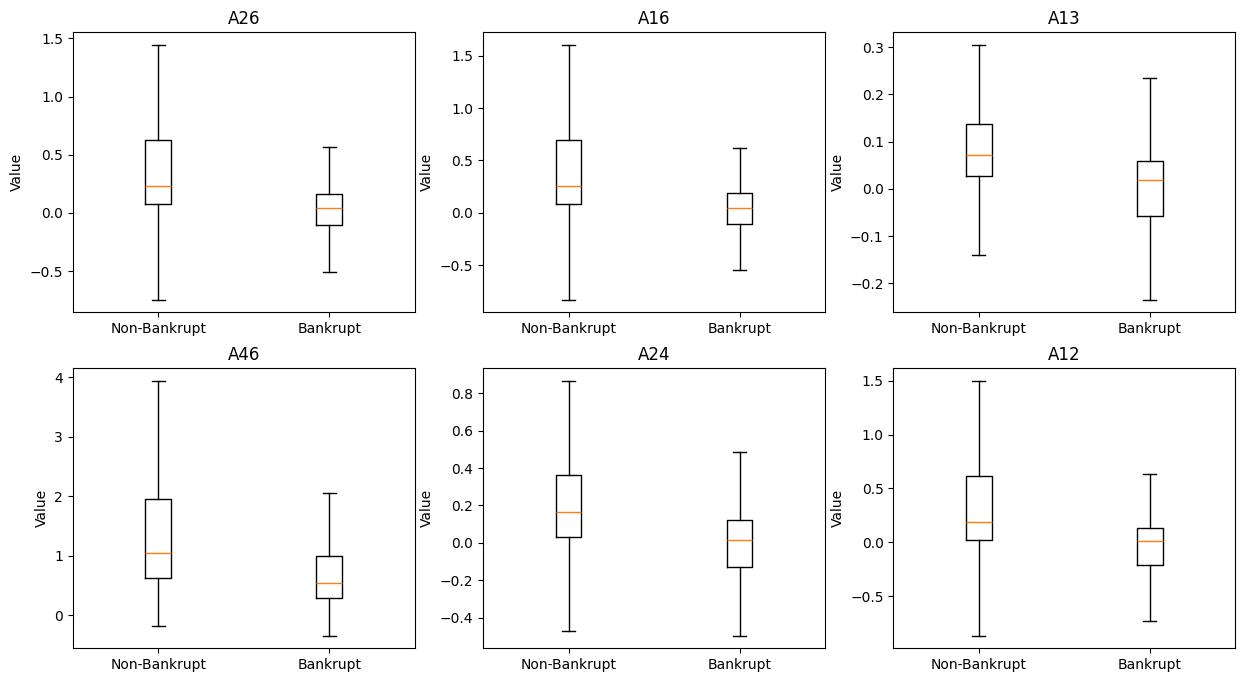

In [8]:

# 3. year별 표본 수와 부도율 확인

summary = (
    data.groupby("year")["class"]
    .agg(
        n="size", #전체 기업 수
        bad="sum" #부도 기업 수
    )
)

summary["bad_rate"]=(
    summary["bad"] / summary["n"]
).round(4)


summary.loc["total"] = [
    len(data),
    data["class"].sum(),
    round(data["class"].mean(), 4)
]

# print(summary)

# 결측값 확인

missing_rate =(
    X.isna()
    .mean() #결측률
    .sort_values(ascending=False)
)

# print("결측값이 있는 변수 수:", (missing_rate >0).sum())
# print("\n결측률 상위 10개 변수:")
# print(missing_rate.head(10))


missing_by_year=(
    data.groupby("year")[feature_cols]
    .apply(lambda group: group.isna().mean().mean()) #각 변수의 결측률들의 평균의 평균>변수 전체에 대한 평균 결측률
)

# print("\n연도별 평균 결측률:")
# print(missing_by_year)


#중복행 확인

duplicate_cnt = data.duplicated(
    subset = feature_cols
).sum()

# print("재무변수 기준 추가 중복행 수:", duplicate_cnt)


# 변수의 분포와 극단값 확인
desc = X.describe(
    percentiles = [0.01, 0.5, 0.99]
).T

desc["abs_max"] = X.abs().max()

# print(
#     desc[
#         ["count", "1%", "50%", "99%", "abs_max"]
#     ]
#     .sort_values("abs_max", ascending = False)
#     .head(10)
# )


# 무한대와 상수 변수 확인

inf_cnt = np.isinf(X).sum()

# print("무한대가 있는 변수 수 :", (inf_cnt>0).sum())
# print(inf_cnt[inf_cnt>0])

constant_cols=[
    col for col in feature_cols
    if data[col].nunique(dropna=True)<=1
]

# print("상수 변수:", constant_cols)

###### 무한대, 상수 변수 모두 없음.

#클래스 불균형 확인

class_summary=(
    data["class"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

class_summary["rate"]=(
    class_summary["count"] / len(data)
).round(4)

# print(class_summary)

# class_summary["count"].plot(
#     kind = "bar",
#     color = ["steelblue", 'tomato']
# )
#
# plt.title("Class Distribution")
# plt.xlabel("Class (0: Non-bankrupt, 1: Bankrupt)")
# plt.ylabel("Number of Companies")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()


###### 전체 43405개의 기업 중 부도 기업은 2091개, 정상기업은 41314개. (부도율 4.82%)
###### 클래스 불균형 존재 > 모델은 Recall, Precision, F1-score, ROC-AUC, PR-AUC 함께 평가


# 부도 여부와 관련성이 큰 변수 확인


target_corr = X.corrwith( #각 재무변수와 부도 여부 사이의 Spearman 상관계수
    data["class"],
    method="spearman"
)

target_corr_table = pd.DataFrame(
    {
        "correlation": target_corr,
        "abs_correlation": target_corr.abs()
    }
)

target_corr_table = target_corr_table.sort_values(
    "abs_correlation",
    ascending=False
)

# print(target_corr_table.head(10))


############################################################
###### 재무변수에 극단값 존재하므로 실제 값 자체보다 값의 순위를 이용
###### A26이 -0.165로 가장 큰 상관관계 보임.
###### 상위 10개가 모두 음수> 값이 클수록 보두 가능성이 낮아지는 방향
###### 말할 수 없음> 가장 큰 절댓값도 0에 가까우므로 변수 하나만으로 부도 구분 어려움
############################################################


# 변수 분포와 변수 간 높은 상관관계 확인


    # 정상기업과 부도기업의 변수 분포 비교
top_features=(
    target_corr_table
    .head(6)
    .index
    .tolist()
)

# print(top_features)

fig, axes =plt.subplots(
    2, 3,
    figsize=(15,8)
)

axes = axes.flatten()

for ax, col in zip(axes, top_features):
    normal = data.loc[
        data["class"] == 0, col
    ].dropna()

    bankrupt = data.loc[
        data["class"] == 1, col
    ].dropna()

    ax.boxplot(
        [normal, bankrupt],
        tick_labels=["Non-Bankrupt", "Bankrupt"],
        showfliers=False
    )

    ax.set_title(col)
    ax.set_ylabel("Value")

# plt.suptitle(
#     "정상기업과 부도기업의 변수 분포 비교"
# )
#
# plt.tight_layout()
# plt.show()

    # 변수끼리 높은 상관관계가 있는지 확인

corr_matrix = X.corr(
    method="spearman"
)

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs=(
    upper_triangle
    .stack()
    .reset_index()
)

corr_pairs.columns =[
    "featrue_1",
    "featrue_2",
    "correlation"
]

corr_pairs["abs_correlation"]=(
    corr_pairs["correlation"].abs()
)


high_corr_pairs = (
    corr_pairs[
        corr_pairs["abs_correlation"]>=0.9
    ]
    .sort_values(
        "abs_correlation",
        ascending=False
    )
)

# print(high_corr_pairs)
# print("높은 상관관계를 가진 변수 쌍 개수:", len(high_corr_pairs))

############################################################
###### 상위 변수의 분포가 정상/부도기업 사이에서 실제로 다른지?
# A1-A64 중 서로 거의 같은 움짐임을 보이는 변수 쌍이 있는지?
###### 상위 6개 변수 : 중앙값(정상>부도), 정상과 부도 사이에 분포의 위치와 사분위 범위도 차이
###### 해당 변수들이 부도 여부와 Spearman 상관 계수 실험 결과가 유지됨을 확인.
######그러나 개별 변수 하나만으로 부도 여부 명확히 구분 어려움.


In [9]:

# =========================================================
# 2. Modeling sample: one-year bankruptcy prediction
# =========================================================

from sklearn.model_selection import train_test_split

# year=5:
# 재무제표 관측 후 1년 이내 부도 여부를 예측하는 표본
model_data = data.loc[
    data["year"] == 5,
    feature_cols + ["class"]
].copy()

X_model = model_data[feature_cols].copy()
y_model = model_data["class"].copy()

# print("모델링 표본 크기:", model_data.shape)
# print("\n부도 여부:")
# print(y_model.value_counts().sort_index())
# print("\n부도율:")
# print(y_model.value_counts(normalize=True).sort_index())

# 전체의 60%는 훈련, 40%는 임시 표본
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.40,
    stratify=y_model,
    random_state=42
)

# 임시 표본을 검증 20%, 테스트 20%로 분할
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

split_summary = pd.DataFrame({
    "sample": ["train", "validation", "test"],
    "n": [
        len(y_train),
        len(y_valid),
        len(y_test)
    ],
    "bad": [
        y_train.sum(),
        y_valid.sum(),
        y_test.sum()
    ],
    "bad_rate": [
        y_train.mean(),
        y_valid.mean(),
        y_test.mean()
    ]
})

# print(split_summary)


In [12]:
missing_threshold = 0.30

high_missing_cols = train_quality.index[
    train_quality["missing_rate"] >= missing_threshold
].tolist()

constant_cols = train_quality.index[
    train_quality["n_unique"] <= 1
].tolist()

excluded_quality_cols = sorted(
    set(high_missing_cols + constant_cols)
)

candidate_cols = [
    col for col in feature_cols
    if col not in excluded_quality_cols
]

print("결측률 30% 이상 변수:", high_missing_cols)
print("상수 변수:", constant_cols)
print("품질 기준 제외 변수:", excluded_quality_cols)
print("남은 후보 변수 수:", len(candidate_cols))

결측률 30% 이상 변수: ['A37']
상수 변수: []
품질 기준 제외 변수: ['A37']
남은 후보 변수 수: 63


In [13]:
missing_threshold = 0.30

high_missing_cols = train_missing_rate[
    train_missing_rate >= missing_threshold
].index.tolist()

candidate_cols = [
    col for col in feature_cols
    if col not in high_missing_cols
]

print("결측률 30% 이상 변수:", high_missing_cols)
print("제외 후 후보 변수 수:", len(candidate_cols))

NameError: name 'train_missing_rate' is not defined